## Problem Statement:

- For loan management firms it's crucial to understand the nature of their customers, whether they will default on their loan or not. 
- They have to be sure that whatever amount they are providing as a loan will be returned to them with interest.
- If they fail to predict this their business will suffer losses and they would not be able to provide loans to new customers.
- In this project based on the customer's financial stability and demographic data we will predict whether the person is likely to default on their loan or not.
- Based on our prediction and reasoning, the bank can decide whether to give a loan to the customer or not, if so they can add excess interest or cap the amount given to such customers.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Understanding:

In [2]:
df = pd.read_csv("Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [4]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [5]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

- There are no missing values available in the dataset.

In [6]:
df["Default"].value_counts(normalize=True)

Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

<Axes: xlabel='Default', ylabel='count'>

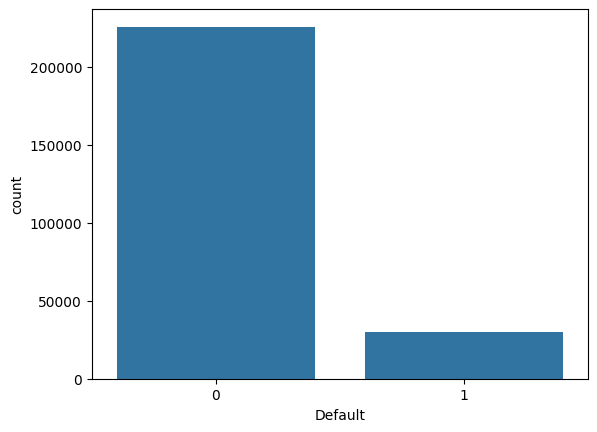

In [7]:
sns.countplot(x='Default',data=df)

- As we can see in the graph, the defaulter data is Imbalanced.
- Total of 88.39% customers have been marked as non-defaulters while 11.61% customers have been marked as defaulters.
- We can not rely only on accuracy parameter, but we have to look for other parameters such as f1 score, classification matrix etc. 

## Data cleaning:

- Now we will remove data points which are of no significant use for us inorder to predict the defaulters.
- The 'LoanID' column doesn't add any significant value for our model so we can safely remove that column.

In [8]:
df = df.drop('LoanID', axis=1)

In [9]:
df.groupby(['DTIRatio'])['Default'].mean()

DTIRatio
0.10    0.107387
0.11    0.110456
0.12    0.096464
0.13    0.107154
0.14    0.104089
          ...   
0.86    0.132560
0.87    0.122462
0.88    0.120581
0.89    0.127632
0.90    0.104673
Name: Default, Length: 81, dtype: float64

In [10]:
df.groupby(['LoanAmount','LoanPurpose'])['Default'].mean()

LoanAmount  LoanPurpose
5000        Home           1.0
5001        Education      0.0
5005        Education      0.0
5006        Education      0.0
5009        Education      0.0
                          ... 
249993      Business       0.5
249996      Home           0.0
249997      Other          0.0
249998      Education      0.0
249999      Business       0.0
Name: Default, Length: 230372, dtype: float64

<Axes: xlabel='Default', ylabel='LoanAmount'>

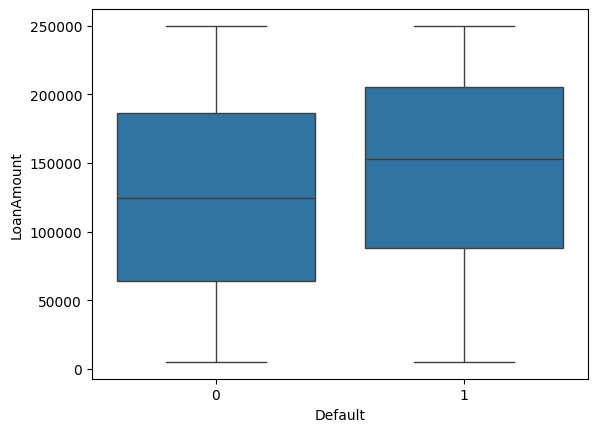

In [11]:
sns.boxplot(x='Default',y='LoanAmount',data=df)

In [12]:
df.groupby(['HasMortgage'])['Default'].mean()

HasMortgage
No     0.123451
Yes    0.108806
Name: Default, dtype: float64

In [13]:
df.groupby('HasCoSigner')['Default'].mean()

HasCoSigner
No     0.128661
Yes    0.103601
Name: Default, dtype: float64

In [14]:
df.groupby('MaritalStatus')['Default'].mean()

MaritalStatus
Divorced    0.125328
Married     0.103972
Single      0.119124
Name: Default, dtype: float64

In [15]:
df.groupby('Education')['Default'].mean()

Education
Bachelor's     0.121011
High School    0.128789
Master's       0.108717
PhD            0.105860
Name: Default, dtype: float64

In [16]:
df['Education'].value_counts(normalize=True)

Education
Bachelor's     0.252073
High School    0.250259
Master's       0.248842
PhD            0.248826
Name: proportion, dtype: float64

In [17]:
df.groupby(['Education'])['Income'].mean()

Education
Bachelor's     82580.142622
High School    82294.182949
Master's       82835.208936
PhD            82287.789587
Name: Income, dtype: float64

In [18]:
df.groupby(['MaritalStatus','HasCoSigner'])['Default'].mean()

MaritalStatus  HasCoSigner
Divorced       No             0.139226
               Yes            0.111525
Married        No             0.115683
               Yes            0.092165
Single         No             0.131207
               Yes            0.107072
Name: Default, dtype: float64

In [19]:
df.groupby('LoanTerm')['Default'].mean()

LoanTerm
12    0.116176
24    0.116078
36    0.115685
48    0.115741
60    0.116961
Name: Default, dtype: float64

In [20]:
df.groupby('NumCreditLines')['Default'].mean()

NumCreditLines
1    0.105233
2    0.110588
3    0.119247
4    0.129424
Name: Default, dtype: float64

In [21]:
df.groupby('LoanPurpose')['Default'].mean()

LoanPurpose
Auto         0.118814
Business     0.123260
Education    0.118381
Home         0.102348
Other        0.117885
Name: Default, dtype: float64

<Axes: xlabel='NumCreditLines', ylabel='Default'>

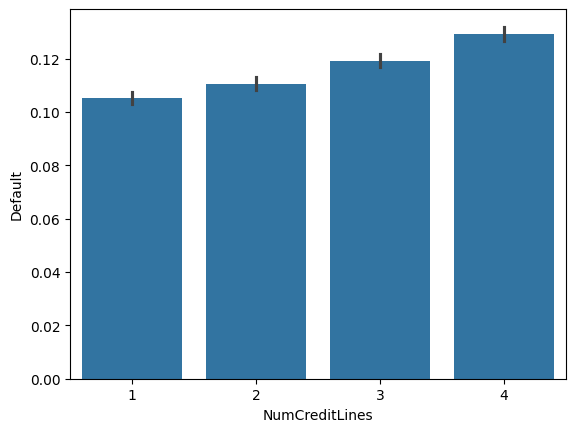

In [22]:
sns.barplot(x='NumCreditLines',y='Default',data=df)

In [23]:
df.groupby(['EmploymentType','HasCoSigner'])['Default'].mean()

EmploymentType  HasCoSigner
Full-time       No             0.104603
                Yes            0.084720
Part-time       No             0.132184
                Yes            0.107035
Self-employed   No             0.127139
                Yes            0.102100
Unemployed      No             0.150587
                Yes            0.120518
Name: Default, dtype: float64

In [24]:
df.groupby(['Age'])['Default'].mean()

Age
18    0.221949
19    0.220834
20    0.223411
21    0.202904
22    0.221328
23    0.187131
24    0.193674
25    0.188430
26    0.181354
27    0.183013
28    0.178557
29    0.161973
30    0.155228
31    0.160554
32    0.157174
33    0.148347
34    0.142170
35    0.140294
36    0.140236
37    0.129530
38    0.131181
39    0.114820
40    0.113331
41    0.111319
42    0.114304
43    0.102518
44    0.100693
45    0.097292
46    0.097811
47    0.094910
48    0.091268
49    0.087439
50    0.092544
51    0.083675
52    0.082982
53    0.068663
54    0.078846
55    0.067733
56    0.073439
57    0.064569
58    0.060823
59    0.058715
60    0.058047
61    0.053392
62    0.053811
63    0.049979
64    0.055372
65    0.057887
66    0.044825
67    0.047375
68    0.047398
69    0.044426
Name: Default, dtype: float64

## EDA Conclusions:

- Customer with better credit score and DTI score tend to default less.
- Customer with age more than 45 years have default rate of less than 10%.
- Customer with Home loans have default rate of less than 10%.
- Married customers and customers with co-signer have default rate of less than 10%.
- From a business point of view it is better to have a co-signer, this reduces default rate by 2%.
- Unemployed customers with a co-signer reduces default rate by 3% with compare to unemployed customer without a co-signer.
- Customer with master's or Phd degree reduces default rate by 2%.

## Business Recommendations

- Encourage co-signers for high-risk customers
- Provide stricter checks for high DTI ratio applicants
- Offer better loan terms for financially stable customers (married, employed)
- Monitor high-risk groups such as younger and unemployed customers more closely

- Now we will encode object columns using get dummies. 

In [25]:
X = df.drop('Default',axis=1)
y = df['Default']

X = pd.get_dummies(X,drop_first=True)

## Train test split:

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Model training:

- As our target varible has categorical values (0/1) we will use classification models. 

### Logistic Regression:

In [27]:
from sklearn.linear_model import LogisticRegression
model_LR = LogisticRegression(random_state=42,max_iter=1000, class_weight='balanced')
model_LR.fit(X_train,y_train)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [28]:
y_pred_LR = model_LR.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [30]:
print("Accuracy LR: ", accuracy_score(y_test,y_pred_LR))
print("Confursion metrix LR: ", confusion_matrix(y_test,y_pred_LR))

Accuracy LR:  0.6738398276874877
Confursion metrix LR:  [[30409 14761]
 [ 1896  4004]]


In [31]:
print("classification report LR", classification_report(y_test,y_pred_LR))
print("f1 score LR", f1_score(y_test,y_pred_LR))

classification report LR               precision    recall  f1-score   support

           0       0.94      0.67      0.79     45170
           1       0.21      0.68      0.32      5900

    accuracy                           0.67     51070
   macro avg       0.58      0.68      0.55     51070
weighted avg       0.86      0.67      0.73     51070

f1 score LR 0.3246705858503953


### Decision Tree:

In [32]:
from sklearn.tree import DecisionTreeClassifier
model_tree = DecisionTreeClassifier(max_depth=10, class_weight='balanced')
model_tree.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=10)

In [33]:
y_pred_tree = model_tree.predict(X_test)

In [34]:
print("Accuracy tree: ", accuracy_score(y_test,y_pred_tree))
print("Confursion metrix tree: ", confusion_matrix(y_test,y_pred_tree))

Accuracy tree:  0.6848051693753672
Confursion metrix tree:  [[31272 13898]
 [ 2199  3701]]


In [35]:
print("classification report tree", classification_report(y_test,y_pred_tree))
print("f1 score LR", f1_score(y_test,y_pred_tree))

classification report tree               precision    recall  f1-score   support

           0       0.93      0.69      0.80     45170
           1       0.21      0.63      0.31      5900

    accuracy                           0.68     51070
   macro avg       0.57      0.66      0.56     51070
weighted avg       0.85      0.68      0.74     51070

f1 score LR 0.314992127324567


### Random Forest with grid search CV:

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

grid.best_params_

{'max_depth': 10, 'n_estimators': 100}

In [37]:
from sklearn.ensemble import RandomForestClassifier
model_RF = RandomForestClassifier(max_depth=10,n_estimators=50, class_weight='balanced')
model_RF.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=50)

In [38]:
y_pred_RF = model_RF.predict(X_test)

In [39]:
print("Accuracy RF: ", accuracy_score(y_test,y_pred_RF))
print("Confursion metrix RF: ", confusion_matrix(y_test,y_pred_RF))

Accuracy RF:  0.7308596044644605
Confursion metrix RF:  [[33662 11508]
 [ 2237  3663]]


In [40]:
print("classification report RF", classification_report(y_test,y_pred_RF))
print("f1 score RF", f1_score(y_test,y_pred_RF))

classification report RF               precision    recall  f1-score   support

           0       0.94      0.75      0.83     45170
           1       0.24      0.62      0.35      5900

    accuracy                           0.73     51070
   macro avg       0.59      0.68      0.59     51070
weighted avg       0.86      0.73      0.77     51070

f1 score RF 0.34768164776232735


In [41]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

model_xgb.fit(X_train, y_train)

# y_pred_xgb = model_xgb.predict(X_test)

y_prob_xgb = model_xgb.predict_proba(X_test)[:,1]

# change threshold
y_pred_xgb = (y_prob_xgb > 0.2).astype(int)

C:\Users\Dell\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:06:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [42]:
print("Accuracy XGB: ", accuracy_score(y_test,y_pred_xgb))
print("Confursion metrix XGB: ", confusion_matrix(y_test,y_pred_xgb))

Accuracy XGB:  0.8194047385940866
Confursion metrix XGB:  [[39325  5845]
 [ 3378  2522]]


In [43]:
print("classification report XGB", classification_report(y_test,y_pred_xgb))
print("f1 score XGB", f1_score(y_test,y_pred_xgb))

classification report XGB               precision    recall  f1-score   support

           0       0.92      0.87      0.90     45170
           1       0.30      0.43      0.35      5900

    accuracy                           0.82     51070
   macro avg       0.61      0.65      0.62     51070
weighted avg       0.85      0.82      0.83     51070

f1 score XGB 0.35354314151538513


- So the Random Forest model provide us with best f1 score, eventhough the accuracy for almost all models is equivalent, but as we have an imbalanced dataset the best performing model is decision tree.

In [44]:
feature_importance = pd.Series(model_xgb.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

Age                          0.116112
InterestRate                 0.065841
HasCoSigner_Yes              0.063503
HasDependents_Yes            0.059889
Income                       0.058772
EmploymentType_Unemployed    0.055320
MonthsEmployed               0.051926
LoanAmount                   0.050461
MaritalStatus_Married        0.046817
LoanPurpose_Home             0.040985
dtype: float32

<Axes: >

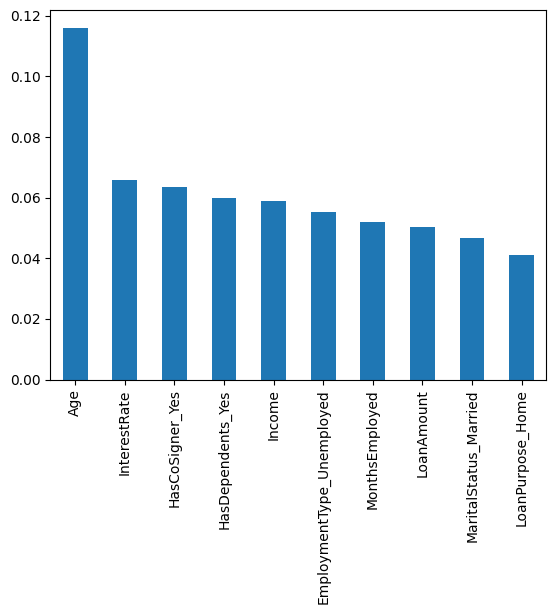

In [45]:
importances = model_xgb.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')

In [46]:
from sklearn.metrics import roc_auc_score

y_prob_LR = model_LR.predict_proba(X_test)[:,1]
y_prob_tree = model_tree.predict_proba(X_test)[:,1]
y_prob_RF = model_RF.predict_proba(X_test)[:,1]
y_prob_xgb = model_xgb.predict_proba(X_test)[:,1]

print('ROC-AUC LR',roc_auc_score(y_test, y_pred_LR))
print('ROC-AUC Tree',roc_auc_score(y_test, y_pred_tree))
print('ROC-AUC RF',roc_auc_score(y_test, y_pred_RF))
print("ROC-AUC XGB:", roc_auc_score(y_test, y_prob_xgb))

ROC-AUC LR 0.6759281884256463
ROC-AUC Tree 0.6598030228552774
ROC-AUC RF 0.6830382960041727
ROC-AUC XGB: 0.7435651906357528


## Final Conclusion

- XGBoost performed best after threshold tuning, achieving an F1-score of 0.35 and ROC-AUC of 0.74.

- Initially, the model underperformed due to the default classification threshold. By lowering the threshold to 0.2, the model improved its ability to detect defaulters, resulting in a better balance between precision and recall.

- Key factors influencing loan default include Age, Interest Rate, Income, and Loan Amount.

- From a business perspective, financial institutions should adopt risk-based lending strategies. This includes focusing on customers with unstable income, high loan amounts relative to income, and higher interest rates.

- Additionally, encouraging co-signers for high-risk applicants and closely monitoring early-stage borrowers can help reduce default risk.